In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine

import scipy.stats as stats
from scipy.stats import ttest_ind

from dotenv import load_dotenv
import os


In [3]:
load_dotenv()



# MySQL connection
username=os.getenv("DB_USERNAME")
password=os.getenv("DB_PASSWORD")
host=os.getenv("DB_HOST")
port=os.getenv("DB_PORT")
database=os.getenv("DB")

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

In [4]:
df=pd.read_sql("Select * from vendor_sales_summary",engine)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrices,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080.0,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038.0,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407.0,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682.0,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109.0,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [5]:
df.shape

(10692, 18)

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.000000,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,18039.228769,12662.187074,58.000000,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,24.385303,109.269375,0.360000,6.840000,10.455000,19.482500,5.681810e+03
ActualPrices,10692.0,35.643671,148.246016,0.490000,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,847.360550,664.309212,50.000000,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3140.886831,11095.086769,1.000000,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,30106.693372,123067.799627,0.710000,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3077.482136,10952.851391,0.000000,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,42239.074419,167655.265984,0.000000,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,18793.783627,44952.773386,0.000000,289.710000,2857.800000,16059.562500,6.728193e+05


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10692 entries, 0 to 10691
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorNumber           10692 non-null  int64  
 1   VendorName             10692 non-null  object 
 2   Brand                  10692 non-null  int64  
 3   Description            10692 non-null  object 
 4   PurchasePrice          10692 non-null  float64
 5   ActualPrices           10692 non-null  float64
 6   Volume                 10692 non-null  float64
 7   TotalPurchaseQuantity  10692 non-null  float64
 8   TotalPurchaseDollars   10692 non-null  float64
 9   TotalSalesQuantity     10692 non-null  float64
 10  TotalSalesDollars      10692 non-null  float64
 11  TotalSalesPrice        10692 non-null  float64
 12  TotalExciseTax         10692 non-null  float64
 13  FreightCost            10692 non-null  float64
 14  GrossProfit            10692 non-null  float64
 15  Pr

In [14]:
numerical_features=df.select_dtypes(include=np.number)

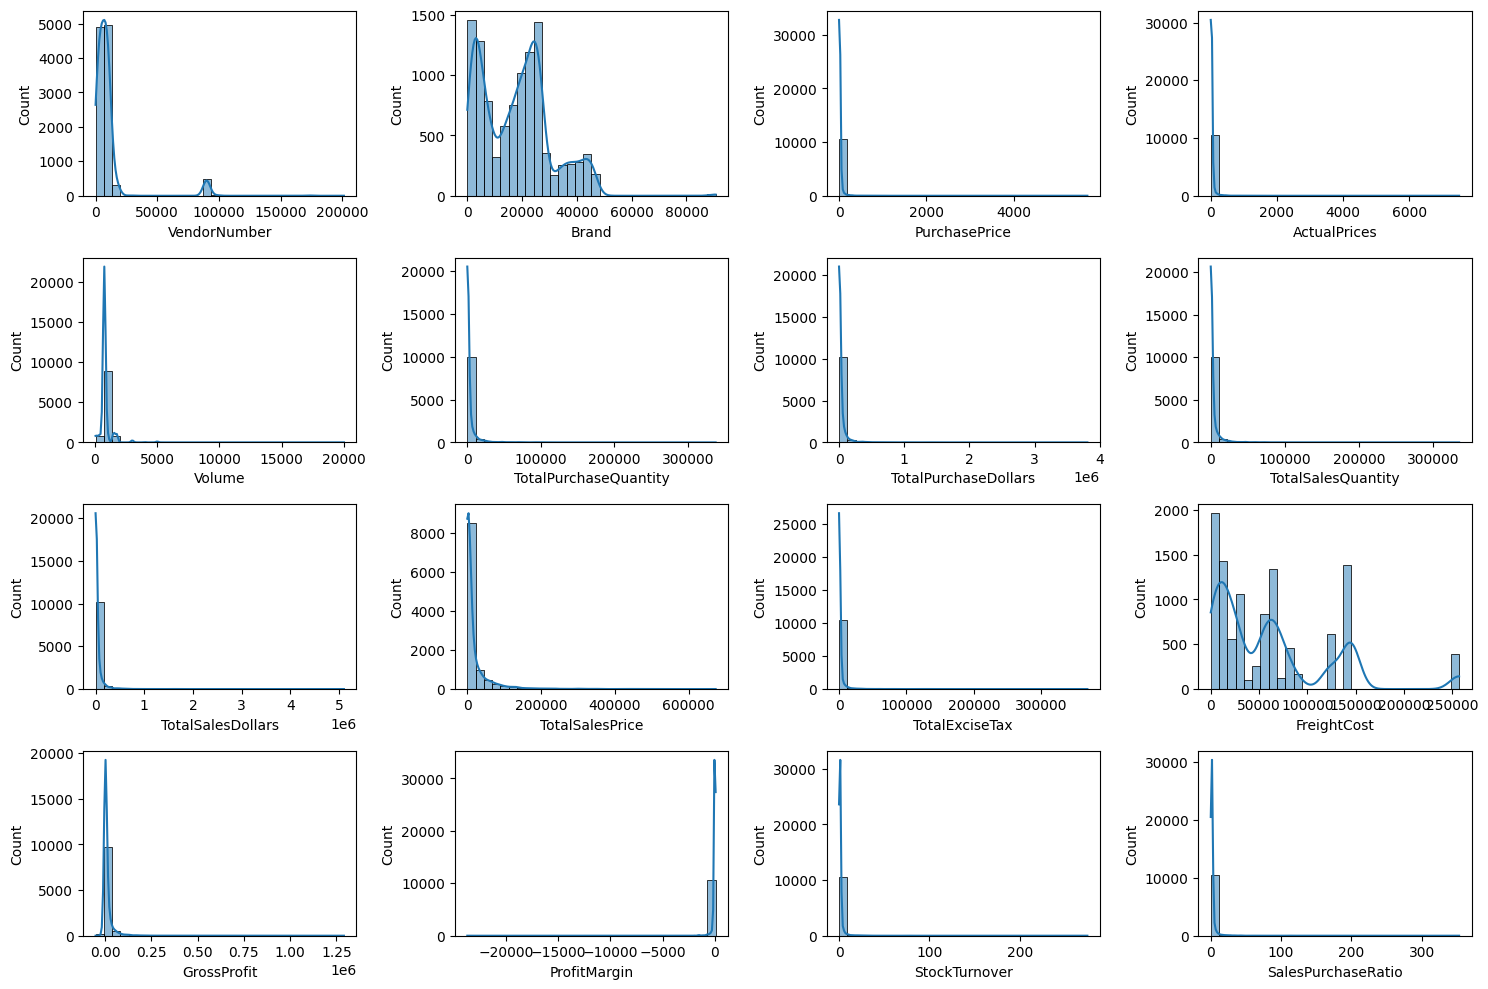

In [15]:

plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_features.columns):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col],kde=True,bins=30)
    
    

plt.tight_layout()
plt.show()

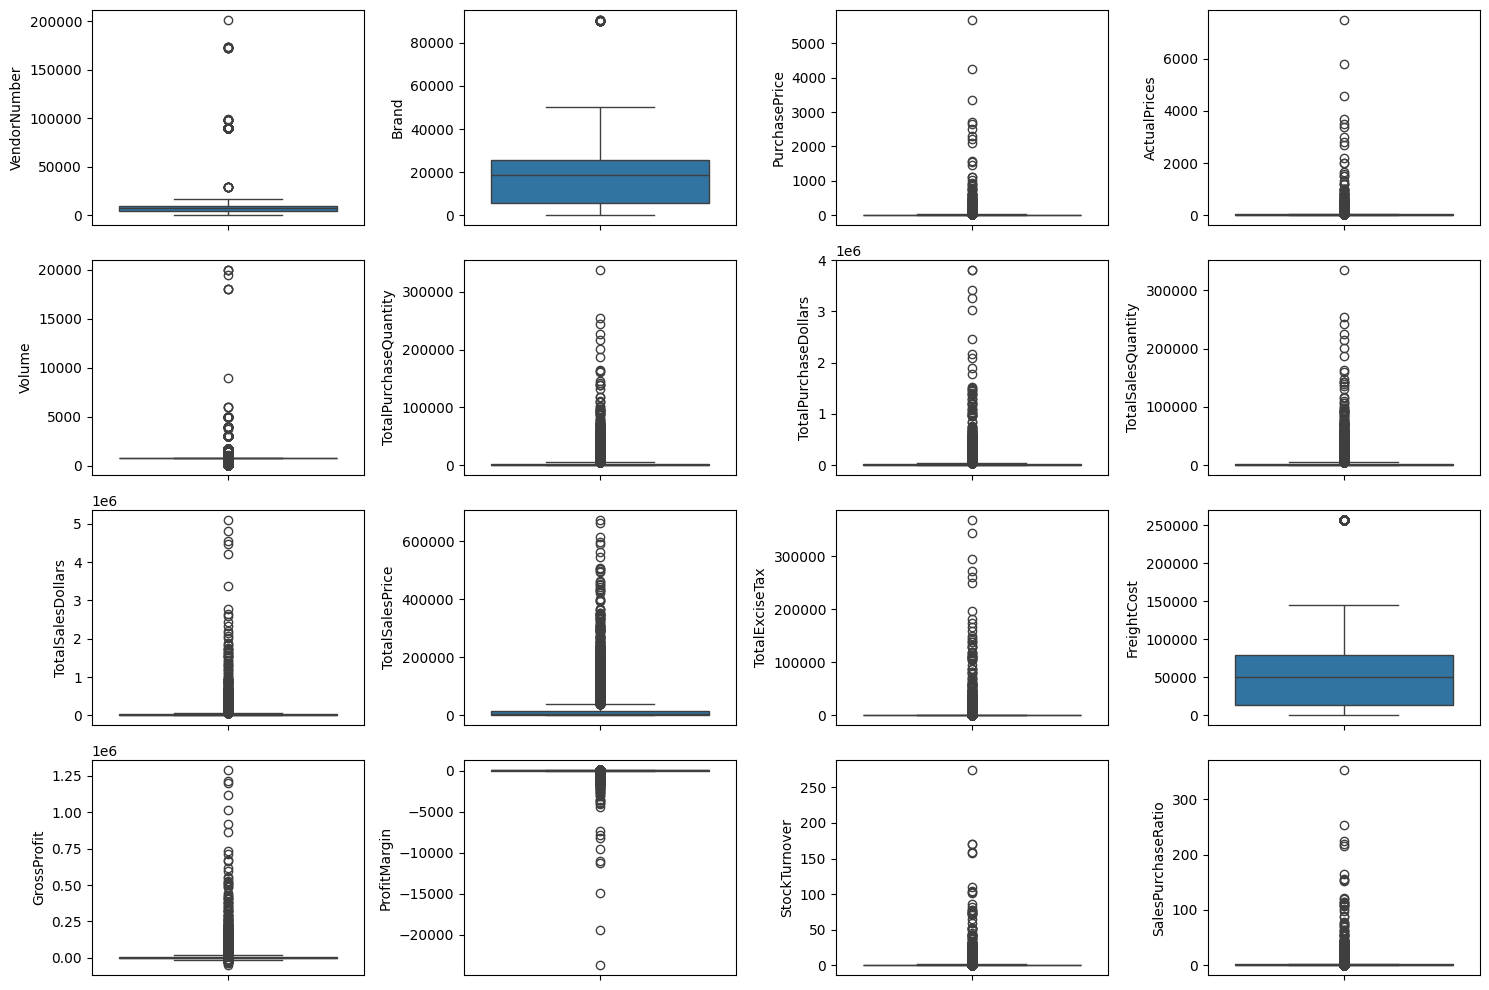

In [16]:

plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_features.columns):
    plt.subplot(4,4,i+1)
    sns.boxplot(df[col])
    
    

plt.tight_layout()
plt.show()

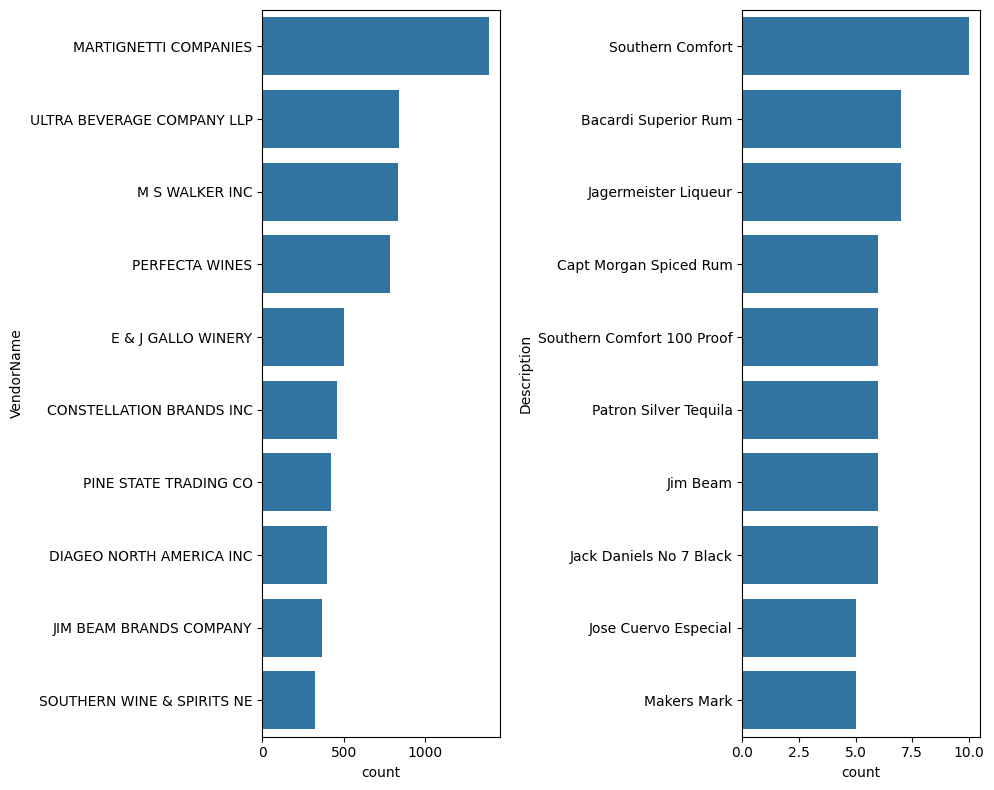

In [17]:
categorical_col=['VendorName','Description']


plt.figure(figsize=(10,8))
for i,col in enumerate(categorical_col):
    plt.subplot(1,2,i+1)
    sns.countplot(df[col],order=df[col].value_counts().index[:10]) #Top 10 category
    
    
plt.tight_layout()
plt.show()

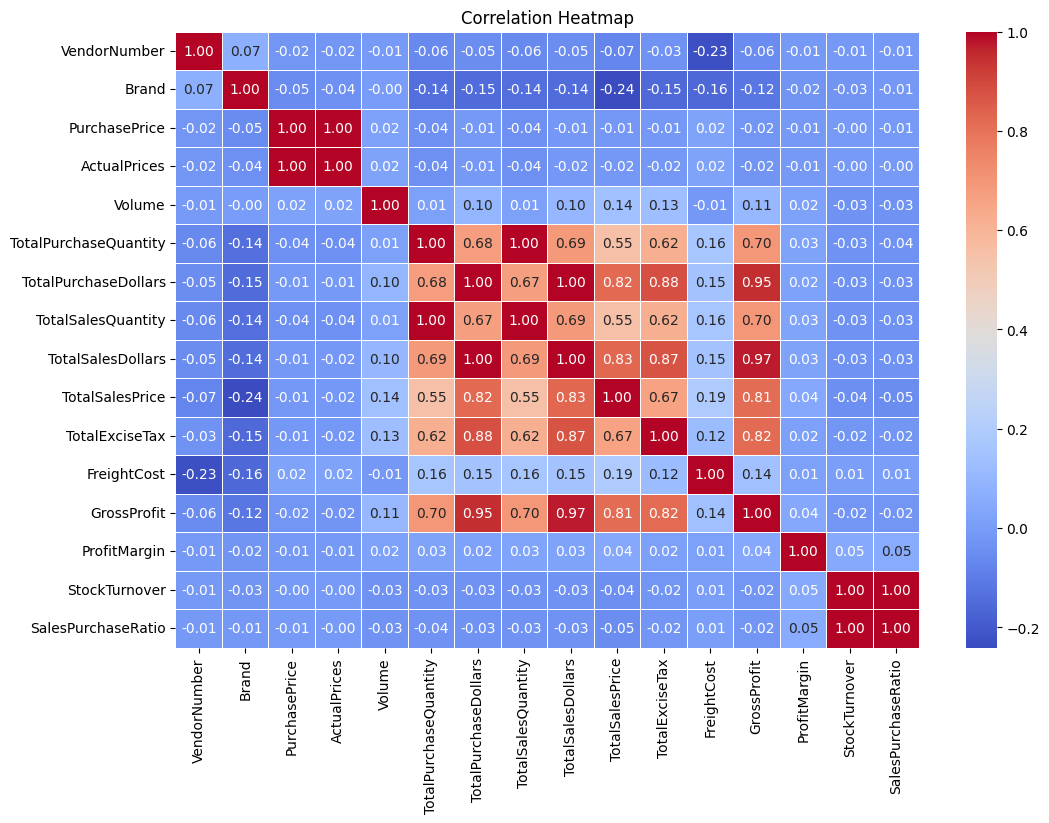

In [18]:
plt.figure(figsize=(12,8))
correlation_matrix=df[numerical_features.columns].corr()
sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

### Observations

#### Negative & zero values : 

* **Gross Profit** : Minimum value is -52002.78, indicating loss.
* **Profit Margin** : Minimum value is -23730.63, which suggests cases where revenue is zero or even lower than costs.
* **Total sales & sales dollars** : Minimum value is 0, means some products were purchased but never sold.

#### Outliers indicated by high standard deviations : 
* **Purchase & Actual prices** : The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.
* **Freight Cost** : Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
* **Stock Turnover** : Ranges from 0 to 274.5, implying some products sell extremely fast while other remain in stock. Value more than 1 indicates that sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.

#### other insights
* PurchasePrice has weak correlations with TotalSalesDollars(-0.012) and GrossProfit(-0.016), suggesting that price variations do not significantly impact sales revenue or profit.
* Strong correlation between TotalPurchaseQuantity and TotalSalesQuantity(0.999), confirming efficient inventory turnover.
* StockTurnover has weak negative correlations with both GrossProfit(-0.038) and ProfitMargin(-0.055), indicating that faster turnover does not necessarily result in higher profitability.

## Data Analysis


**Identify brands that needs promotional or pricing adjustments which exhibit lower sales performance but higher profit margins.**


In [21]:
def format_dollars(value):
    if value>=1_000_000:
        return f"{value/1_000_000:.2f}M"
    elif value>=1_000:
        return f"{value/1_000:.2f}K"
    else:
        return str(value)

In [22]:
brand_performance=df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'
}).reset_index()

In [23]:
low_sales_threshold=brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold=brand_performance['ProfitMargin'].quantile(0.85)

In [24]:
high_margin_threshold

np.float64(56.19805605783905)

In [25]:
mask1=brand_performance['TotalSalesDollars']<=low_sales_threshold
mask2=brand_performance['ProfitMargin']>=high_margin_threshold

traget_brands=brand_performance[mask1 & mask2]

print("Brands with Low sales but high Profit margins : ")
display(traget_brands.sort_values('TotalSalesDollars'))

Brands with Low sales but high Profit margins : 


,Description,TotalSalesDollars,ProfitMargin
7777,Santa Rita Organic Svgn Bl,9.99,66.466466
2896,Debauchery Pnt Nr,11.58,65.975820
2537,Concannon Glen Ellen Wh Zin,15.95,83.448276
2677,Crown Royal Apple,27.86,89.806174
7818,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
8939,Tommasi Poggio Tufo Cab Svgn,269.73,74.789604
9229,Vigne A Porrona Rosso,272.79,96.825397
3980,Gifft Chardonnay,279.80,94.245890
5736,Mad Dogs & Englishmen Jumil,279.80,97.666190


In [27]:
brand_performance=brand_performance[brand_performance['TotalSalesDollars']<10000] # for better visualization

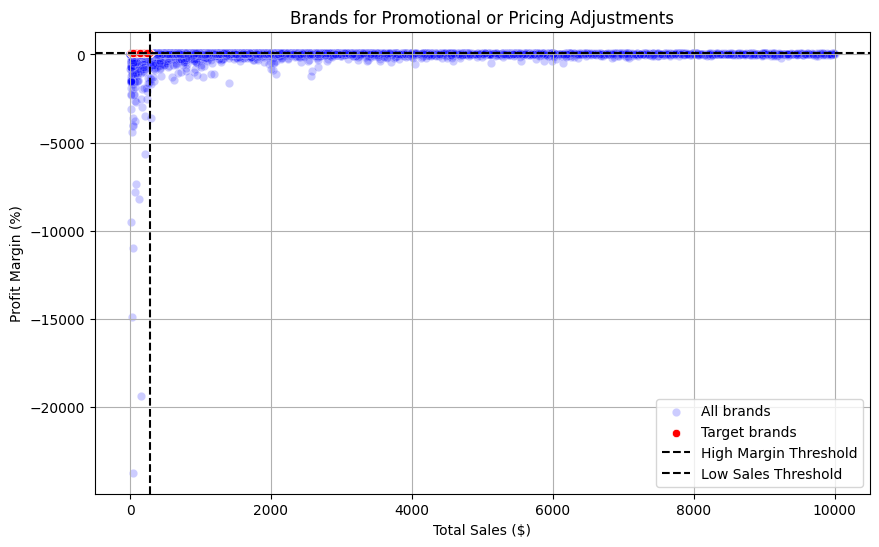

In [28]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance,x='TotalSalesDollars',y='ProfitMargin',color='blue',label='All brands', alpha=0.2)
sns.scatterplot(data=traget_brands,x='TotalSalesDollars',y='ProfitMargin',color='red',label='Target brands')

plt.axhline(high_margin_threshold,linestyle='--',color='black',label="High Margin Threshold")
plt.axvline(low_sales_threshold,linestyle='--',color='black',label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

**Which vendors and brands demonstrate the highest sales performance ?**

In [29]:
top_vendors=df.groupby('VendorName')['TotalSalesDollars'].sum().nlargest(10)
top_product=df.groupby('Description')['TotalSalesDollars'].sum().nlargest(10)

In [32]:
top_vendors.apply(lambda x : format_dollars(x))

VendorName
DIAGEO NORTH AMERICA INC      68.74M
MARTIGNETTI COMPANIES         40.96M
PERNOD RICARD USA             32.28M
JIM BEAM BRANDS COMPANY       31.90M
BACARDI USA INC               25.01M
CONSTELLATION BRANDS INC      24.47M
E & J GALLO WINERY            18.55M
BROWN-FORMAN CORP             18.48M
ULTRA BEVERAGE COMPANY LLP    17.80M
M S WALKER INC                15.44M
Name: TotalSalesDollars, dtype: object

In [31]:
top_product.apply(lambda x : format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: object

C:\Users\Ashish Panchal\AppData\Local\Temp\ipykernel_11920\283075839.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_vendors.index,x=top_vendors.values,palette="Blues_r")
C:\Users\Ashish Panchal\AppData\Local\Temp\ipykernel_11920\283075839.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_product.index,x=top_product.values,palette='Reds_r')


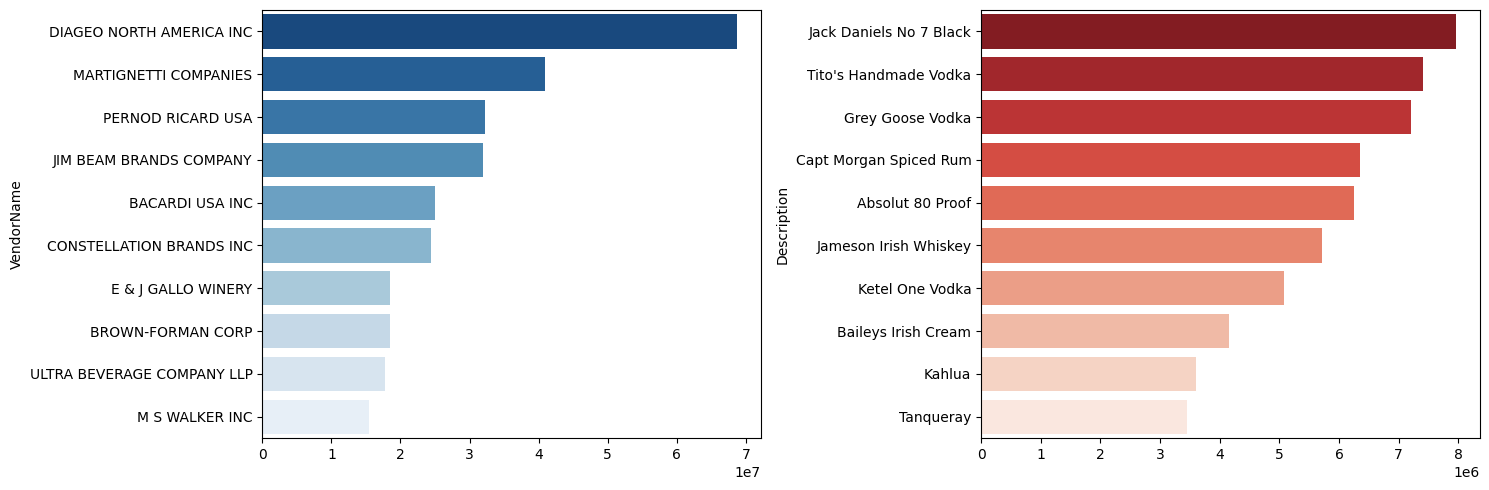

In [33]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
sns.barplot(y=top_vendors.index,x=top_vendors.values,palette="Blues_r")

plt.subplot(1,2,2)
sns.barplot(y=top_product.index,x=top_product.values,palette='Reds_r')

plt.tight_layout()
plt.show()

**Which vendors contribute the most to total purchase dollars?**

In [65]:
vendor_performance=df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()

In [86]:
vendor_performance['PurchaseContribution%']=(vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum())*100

In [87]:
vendor_performance=round(vendor_performance.sort_values('PurchaseContribution%',ascending=False),2)

In [88]:
top_vendors=vendor_performance.head(10)

In [89]:
#display top 10 vendors
top_vendors=vendor_performance.head(10)
top_vendors['TotalSalesDollars']=top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars']=top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit']=top_vendors['GrossProfit'].apply(format_dollars)

C:\Users\Ashish Panchal\AppData\Local\Temp\ipykernel_11920\2018632613.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_vendors['TotalSalesDollars']=top_vendors['TotalSalesDollars'].apply(format_dollars)
C:\Users\Ashish Panchal\AppData\Local\Temp\ipykernel_11920\2018632613.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_vendors['TotalPurchaseDollars']=top_vendors['TotalPurchaseDollars'].apply(format_dollars)
C:\Users\Ashish Panchal\AppData\Local\Temp\ipykernel_11920\2018632613.py:5: SettingWit

In [90]:
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
28,DIAGEO NORTH AMERICA INC,50.96M,17.78M,68.74M,15.83
63,MARTIGNETTI COMPANIES,27.86M,13.10M,40.96M,8.66
50,JIM BEAM BRANDS COMPANY,24.20M,7.70M,31.90M,7.52
74,PERNOD RICARD USA,24.12M,8.16M,32.28M,7.49
8,BACARDI USA INC,17.62M,7.38M,25.01M,5.48
23,CONSTELLATION BRANDS INC,15.57M,8.89M,24.47M,4.84
14,BROWN-FORMAN CORP,13.53M,4.95M,18.48M,4.20
114,ULTRA BEVERAGE COMPANY LLP,13.21M,4.59M,17.80M,4.10
33,E & J GALLO WINERY,12.29M,6.26M,18.55M,3.82
59,M S WALKER INC,10.94M,4.50M,15.44M,3.40


In [91]:
top_vendors["PurchaseContribution%"].sum()

np.float64(65.34)

* top 10 vendors has 65% contribution in purchase

In [92]:
top_vendors['Cumulative_Contribution%']=top_vendors['PurchaseContribution%'].cumsum()

C:\Users\Ashish Panchal\AppData\Local\Temp\ipykernel_11920\2851312941.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_vendors['Cumulative_Contribution%']=top_vendors['PurchaseContribution%'].cumsum()


In [93]:
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
28,DIAGEO NORTH AMERICA INC,50.96M,17.78M,68.74M,15.83,15.83
63,MARTIGNETTI COMPANIES,27.86M,13.10M,40.96M,8.66,24.49
50,JIM BEAM BRANDS COMPANY,24.20M,7.70M,31.90M,7.52,32.01
74,PERNOD RICARD USA,24.12M,8.16M,32.28M,7.49,39.50
8,BACARDI USA INC,17.62M,7.38M,25.01M,5.48,44.98
23,CONSTELLATION BRANDS INC,15.57M,8.89M,24.47M,4.84,49.82
14,BROWN-FORMAN CORP,13.53M,4.95M,18.48M,4.20,54.02
114,ULTRA BEVERAGE COMPANY LLP,13.21M,4.59M,17.80M,4.10,58.12
33,E & J GALLO WINERY,12.29M,6.26M,18.55M,3.82,61.94
59,M S WALKER INC,10.94M,4.50M,15.44M,3.40,65.34


C:\Users\Ashish Panchal\AppData\Local\Temp\ipykernel_11920\3518096017.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'], palette='mako', ax=ax1)
C:\Users\Ashish Panchal\AppData\Local\Temp\ipykernel_11920\3518096017.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)


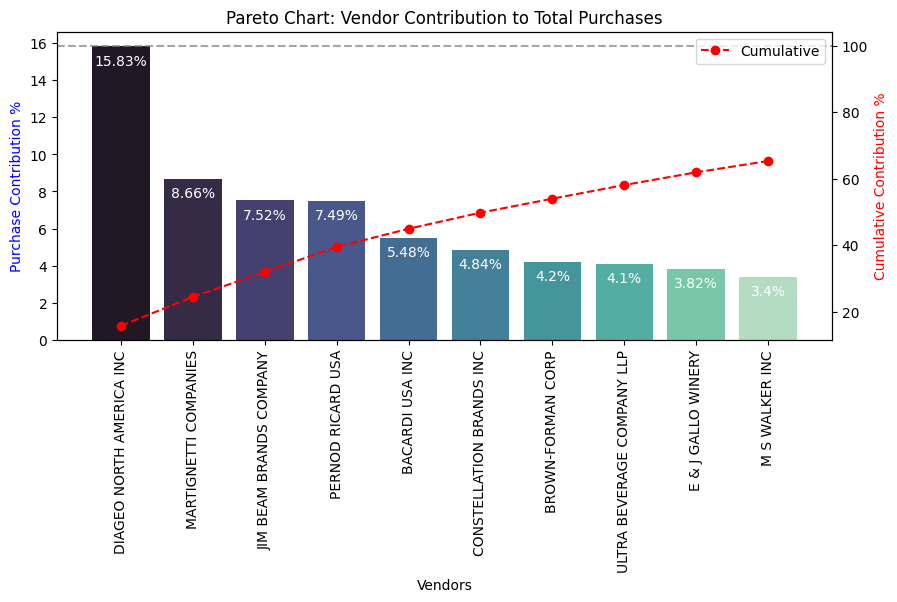

In [94]:
fig, ax1 = plt.subplots(figsize=(10, 4))

# Bar plot for Purchase Contribution
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'], palette='mako', ax=ax1)
for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value - 1, str(value) + '%', ha='center', fontsize=10, color='white')

# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(
    top_vendors['VendorName'],                 # x (positional)
    top_vendors['Cumulative_Contribution%'],    # y (positional)
    color='red', marker='o', linestyle='dashed', label='Cumulative'
)

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')
plt.show()

**How much of total procurement is dependent on the top vendors?**

In [95]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)} %")

Total Purchase Contribution of top 10 vendors is 65.34 %


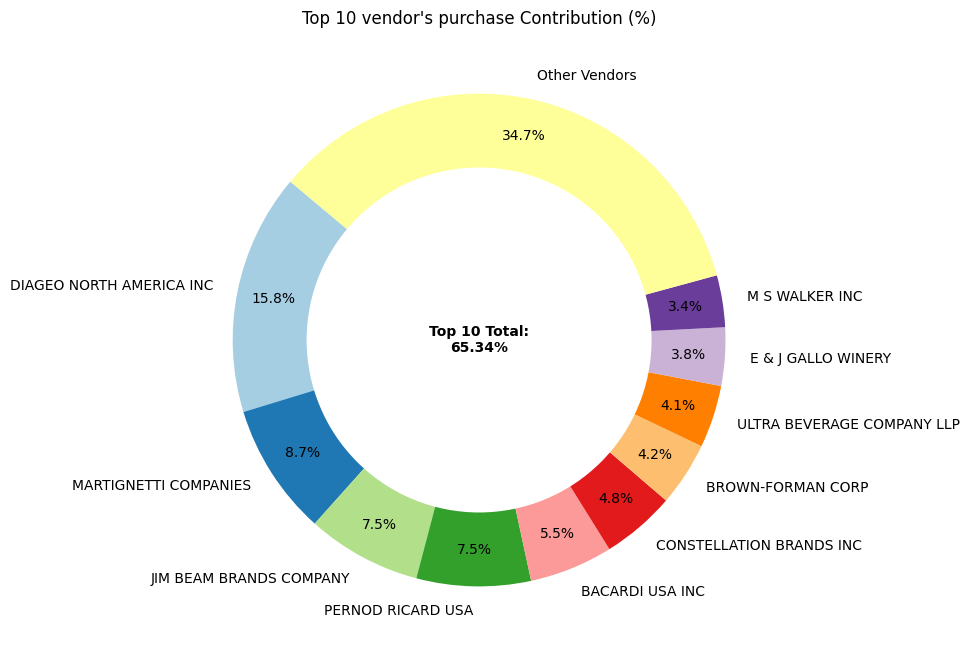

In [96]:
vendors=list(top_vendors['VendorName'].values)
purchase_contributions=list(top_vendors['PurchaseContribution%'].values)

total_contribution=sum(purchase_contributions)
remaining_contribution=100-total_contribution

# Append "other vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)


# Donut chart
fig, ax= plt.subplots(figsize=(8,8))
wedges, texts,autotexts =ax.pie(purchase_contributions,labels=vendors,autopct='%1.1f%%',startangle=140,pctdistance=0.85,colors=plt.cm.Paired.colors)

# Draw a white circle in the center to create a "donut" effect
centre_circle=plt.Circle((0,0),0.70,fc='white')
fig.gca().add_artist(centre_circle)

# Add total contribution annotation in the center
plt.text(0,0,f"Top 10 Total:\n{total_contribution:.2f}%",fontsize=10,fontweight='bold',ha='center',va='center')

plt.title("Top 10 vendor's purchase Contribution (%)")
plt.show()

**Does purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost saving?**

In [97]:
df['UnitPurchasePrice']=df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']

In [98]:
df['OrderSize']=pd.qcut(df['TotalPurchaseQuantity'],q=3,labels=['Small','Medium','Large'])

In [99]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

C:\Users\Ashish Panchal\AppData\Local\Temp\ipykernel_11920\1505448859.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('OrderSize')[['UnitPurchasePrice']].mean()


,UnitPurchasePrice
OrderSize,
Small,43.776954
Medium,17.894005
Large,11.308807


C:\Users\Ashish Panchal\AppData\Local\Temp\ipykernel_11920\567960540.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='OrderSize',y='UnitPurchasePrice',palette='Set2')


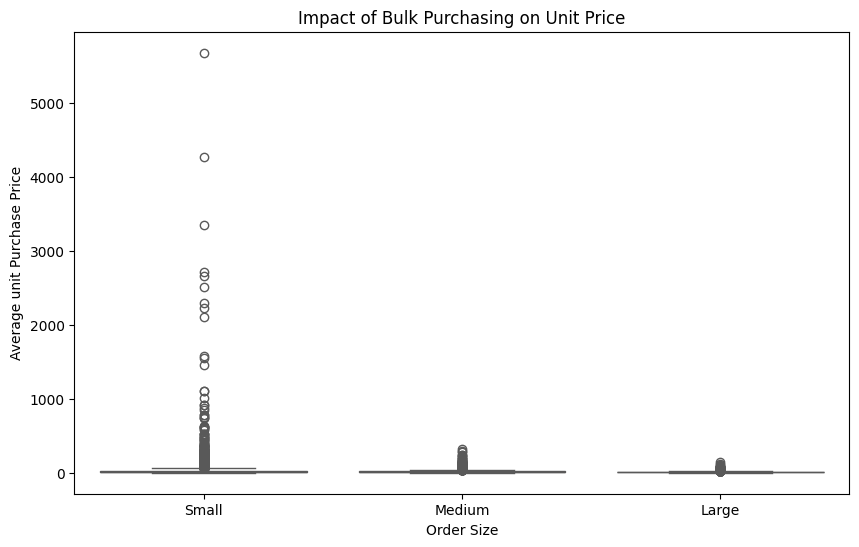

In [100]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='OrderSize',y='UnitPurchasePrice',palette='Set2')
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average unit Purchase Price")
plt.show()

* Vendors buying in bulk get the lowest unit price, means higher margin if they can manage inventory efficiently.
* This suggest that bulk pricing strategies successfully encourage vendors to pruchase in larger volumes, leading to higher overall sales.


**Which vendors have low inventory turnover, indicating excess stock and slow-moving products?**

In [101]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending=True).head(10)

,StockTurnover
VendorName,
AAPER ALCOHOL & CHEMICAL CO,0.000000
LAUREATE IMPORTS CO,0.000000
TRUETT HURST,0.041667
"IRA GOLDMAN AND WILLIAMS, LLP",0.075000
HIGHLAND WINE MERCHANTS LLC,0.148920
UNCORKED,0.217238
MILTONS DISTRIBUTING CO,0.236111
VINEYARD BRANDS LLC,0.256241
LOYAL DOG WINERY,0.308333


**How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it ?**

In [111]:
df['UnsoldInventoryValue']=(df['TotalPurchaseQuantity']-df['TotalSalesQuantity'])*df['PurchasePrice']
format_dollars(df['UnsoldInventoryValue'].sum())

'8.75M'

In [112]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor=df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort vendors with the highest locked capital
inventory_value_per_vendor=inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue",ascending=False)


In [113]:
inventory_value_per_vendor['UnsoldInventoryValue']=inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)

inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
28,DIAGEO NORTH AMERICA INC,980.09K
63,MARTIGNETTI COMPANIES,928.99K
50,JIM BEAM BRANDS COMPANY,857.80K
114,ULTRA BEVERAGE COMPANY LLP,780.27K
73,PERFECTA WINES,571.81K
74,PERNOD RICARD USA,554.74K
59,M S WALKER INC,469.96K
125,WILLIAM GRANT & SONS INC,436.49K
33,E & J GALLO WINERY,315.20K
14,BROWN-FORMAN CORP,284.91K


**What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors?**

In [114]:
top_threshold=df["TotalSalesDollars"].quantile(0.75)
low_threshold=df['TotalSalesDollars'].quantile(0.25)


In [106]:
top_vendors=df[df['TotalSalesDollars'] >= top_threshold]['ProfitMargin'].dropna()
low_vendors=df[df['TotalSalesDollars'] <= low_sales_threshold]['ProfitMargin'].dropna()

In [116]:
low_vendors

2147    -19378.597146
2456         0.000000
2462    -11272.684414
2528         0.000000
2982         0.000000
             ...     
10687       83.448276
10688       96.436186
10689       25.252525
10690       98.974037
10691       99.166079
Name: ProfitMargin, Length: 1608, dtype: float64

In [117]:
def confidence_interval(data,confidence=0.95):
    mean_value=np.mean(data)
    std_err=np.std(data,ddof=1)/np.sqrt(len(data)) # standard error
    t_critical=stats.t.ppf((1+confidence)/2,df=len(data)-1)
    margin_of_error=t_critical*std_err
    return mean_value,mean_value-margin_of_error,mean_value+margin_of_error


Top Vendors 95% CI : (29.53, 30.55), Mean : 30.04
Low Vendors 95% CI : (-261.62, -154.03), Mean : -207.83


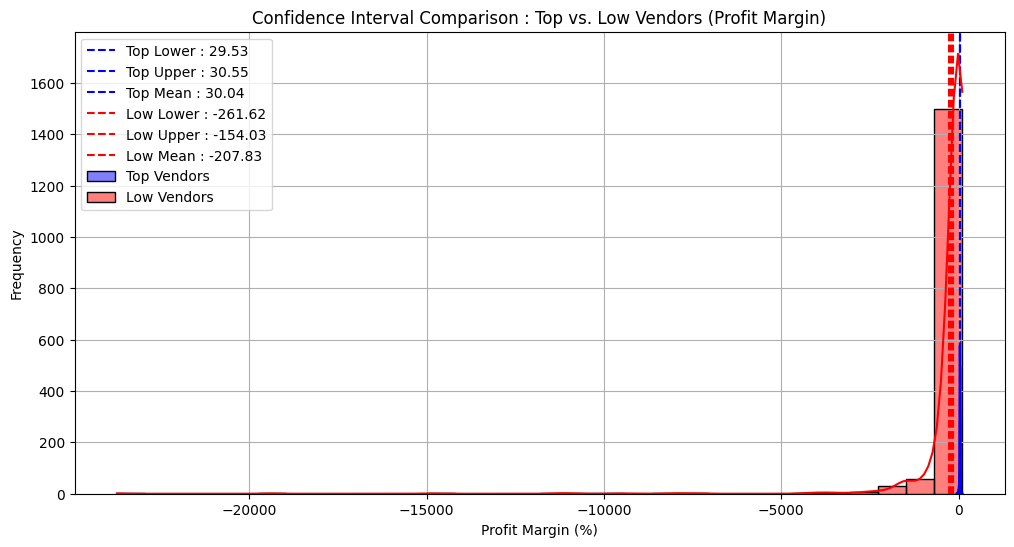

In [118]:
top_mean,top_lower,top_upper=confidence_interval(top_vendors)
low_mean,low_lower,low_upper=confidence_interval(low_vendors)

print(f"Top Vendors 95% CI : ({top_lower:.2f}, {top_upper:.2f}), Mean : {top_mean:.2f}")
print(f"Low Vendors 95% CI : ({low_lower:.2f}, {low_upper:.2f}), Mean : {low_mean:.2f}")

plt.figure(figsize=(12,6))

#Top Vendors plot
sns.histplot(top_vendors,kde=True,color="blue",bins=30,alpha=0.5,label="Top Vendors")
plt.axvline(top_lower,color='blue',linestyle="--",label=f"Top Lower : {top_lower:.2f}")
plt.axvline(top_upper,color='blue',linestyle="--",label=f"Top Upper : {top_upper:.2f}")
plt.axvline(top_mean,color="blue",linestyle="--",label=f"Top Mean : {top_mean:.2f}")



# Low Vendors plot

sns.histplot(low_vendors,kde=True,color="red",bins=30,alpha=0.5,label="Low Vendors")
plt.axvline(low_lower,color='red',linestyle="--",label=f"Low Lower : {low_lower:.2f}")
plt.axvline(low_upper,color='red',linestyle="--",label=f"Low Upper : {low_upper:.2f}")
plt.axvline(low_mean,color="red",linestyle="--",label=f"Low Mean : {low_mean:.2f}")


# Finalize plot
plt.title("Confidence Interval Comparison : Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

#### Hypothesis Testing

Is there a significant difference in profit margins between top-performing and low-performing vendors?



**Null Hypothesis** : There is no significant difference in the mean profit margin of top-performing and low-performing vendors.

**Alternative Hypothesis**  : The mean profit margins of top-performing and low-performing vendors are significantly different.

In [119]:
top_threshold=df["TotalSalesDollars"].quantile(0.75)
low_threshold=df['TotalSalesDollars'].quantile(0.25)

top_vendors=df[df['TotalSalesDollars'] >= top_threshold]['ProfitMargin'].dropna()
low_vendors=df[df['TotalSalesDollars'] <= low_sales_threshold]['ProfitMargin'].dropna()

# Perform two sample t-test
t_stat,p_value=ttest_ind(top_vendors,low_vendors,equal_var=False)

#Result
print(f"T-Statistic : {t_stat:.4f}, P-Value : {p_value:.4f}")
if p_value<0.05:
    print("Reject Null Hypothesis")
    print("There is significant difference in profit margin between top and low performing vendors.")
else:
    print("Fail to reject Null Hypothesis : No significant difference in profit margins.")


T-Statistic : 8.5697, P-Value : 0.0000
Reject Null Hypothesis
There is significant difference in profit margin between top and low performing vendors.
